# Toolbox ML — Notebook de demostración
## Dataset: Diamonds 💎
Este notebook muestra el uso de todas las funciones del paquete `toolbox_ml`
aplicadas al dataset de diamonds de seaborn.

## 📥Importaciones

In [1]:
import seaborn as sns
import pandas as pd
from toolbox_ml.eda.core import (
    describe_df, tipifica_variables, 
    get_features_num_regression, 
    plot_features_num_regression, 
    get_features_cat_regression, 
    plot_features_cat_regression
)

## 🗃️Carga del dataset

In [2]:
df = sns.load_dataset("diamonds")
df.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


## 1️⃣ describe_df
Genera un resumen estadístico del DataFrame mostrando el tipo de dato,
porcentaje de nulos, valores únicos y porcentaje de cardinalidad de cada columna.

In [3]:
resumen = describe_df(df)
resumen

,tipo,porcentaje_nulos,valores_unicos,porcentaje_cardinalidad
carat,float64,0.0,273,0.51
cut,category,0.0,5,0.01
color,category,0.0,7,0.01
clarity,category,0.0,8,0.01
depth,float64,0.0,184,0.34
table,float64,0.0,127,0.24
price,int64,0.0,11602,21.51
x,float64,0.0,554,1.03
y,float64,0.0,552,1.02
z,float64,0.0,375,0.7


## 2️⃣ tipifica_variables
Clasifica automáticamente cada variable del DataFrame en: Binaria, Categórica,
Numérica Discreta o Numérica Continua.

In [4]:
tipos = tipifica_variables(df, umbral_categoria=10, umbral_continua=20.0)
tipos

,nombre_variable,tipo_sugerido
0,carat,Numérica Discreta
1,cut,Categórica
2,color,Categórica
3,clarity,Categórica
4,depth,Numérica Discreta
5,table,Numérica Discreta
6,price,Numérica Continua
7,x,Numérica Discreta
8,y,Numérica Discreta
9,z,Numérica Discreta


## 3️⃣ get_features_num_regression
Devuelve las columnas numéricas que tienen una correlación significativa
con el target. Usamos `price` como variable a predecir.

In [7]:
features_num = get_features_num_regression(df, target_col="price", umbral_corr=0.5, pvalue=0.05)
print("Columnas numéricas con correlación significativa con 'price':", features_num)

Columnas numéricas con correlación significativa con 'price': ['carat', 'x', 'y', 'z']


## 4️⃣ plot_features_num_regression
Pinta pairplots de las columnas numéricas que superan el umbral de correlación
con el target `price`.

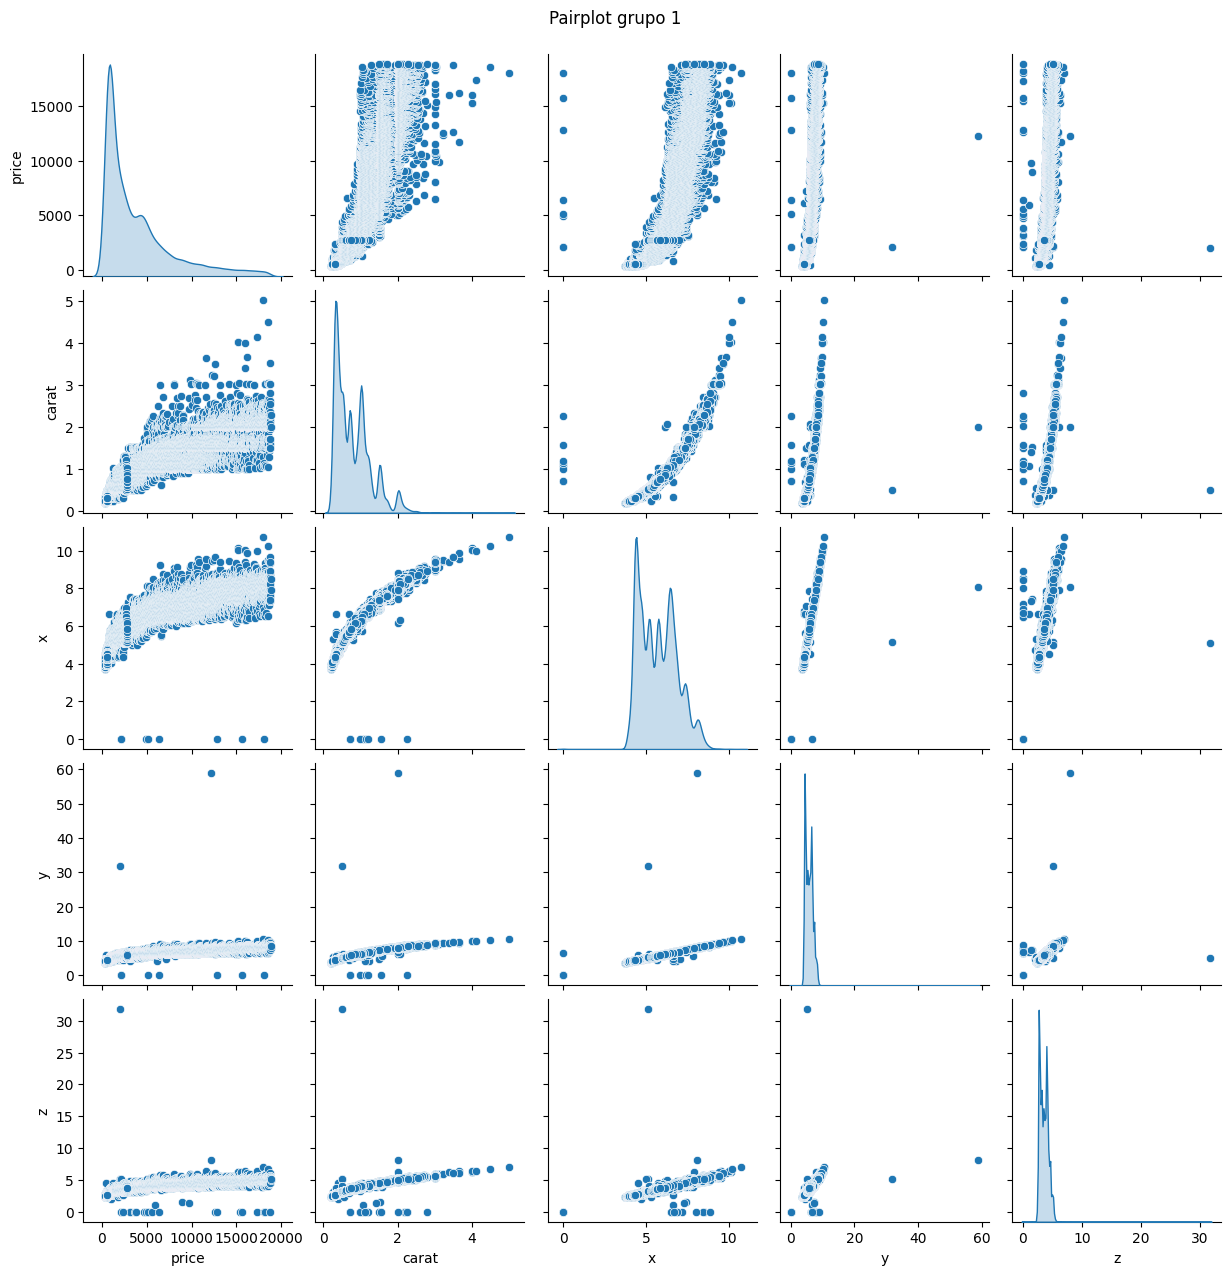

['carat', 'x', 'y', 'z']

In [8]:
plot_features_num_regression(df, target_col="price", columns=features_num, umbral_corr=0.5, pvalue=0.05)

## 5️⃣ get_features_cat_regression
Devuelve las columnas categóricas que tienen una relación estadísticamente
significativa con el target `price`.

In [15]:
features_cat = get_features_cat_regression(df, target_col='price', pvalue=0.05)
print("Columnas categóricas con relación estadísticamente significativa con 'price':", features_cat)

Columnas categóricas con relación estadísticamente significativa con 'price': ['cut', 'color', 'clarity']


## 6️⃣ plot_features_cat_regression
Pinta histogramas agrupados de las columnas categóricas que tienen una relación
estadísticamente significativa con el target `price`.

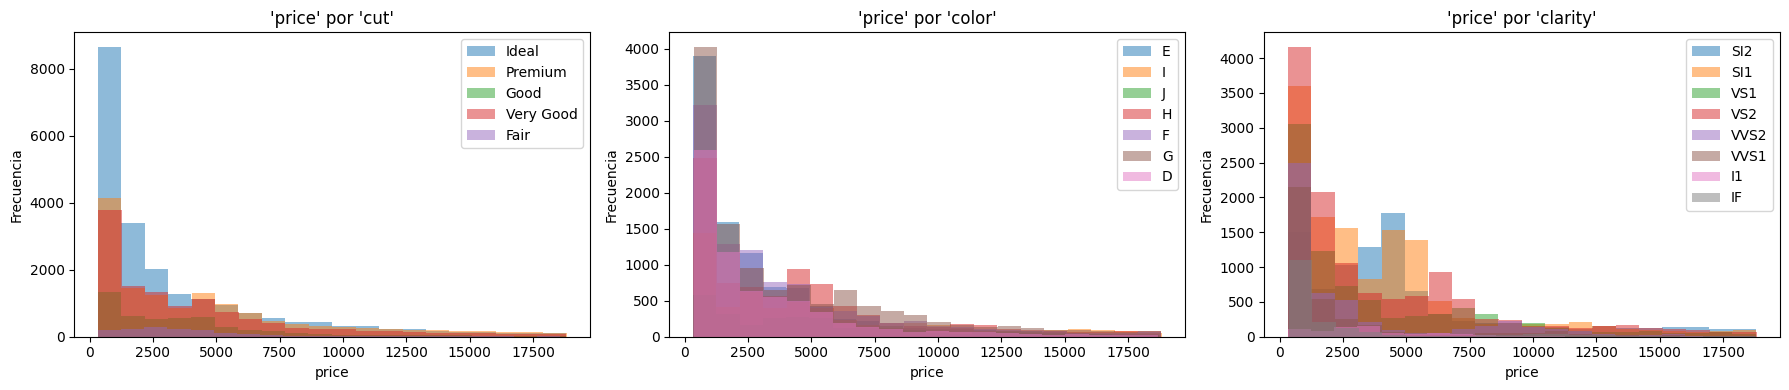

['cut', 'color', 'clarity']

In [10]:
plot_features_cat_regression(df, target_col='price', columns=features_cat, pvalue=0.05, with_individual_plot=False)

## 📝 Conclusiones
- El dataset diamonds tiene 10 variables: 7 numéricas y 3 categóricas.
- Las variables numéricas con mayor correlación con `price` son `carat`, `x`, `y` y `z`.
- Las variables categóricas `cut`, `color` y `clarity` tienen una relación
  estadísticamente significativa con `price`.
- El paquete `toolbox_ml` facilita las tareas más comunes del análisis exploratorio
  de datos y la selección de features para proyectos de Machine Learning.